In [1]:
import pandas as pd
import numpy as np
from scipy import stats 
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score

In [2]:
from sklearn.compose import make_column_transformer,ColumnTransformer
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,VotingRegressor
from xgboost import XGBRegressor 
from sklearn.kernel_ridge import KernelRidge

In [3]:
train_df=pd.read_csv("train.csv")
test_df=pd.read_csv("test.csv")

In [4]:
train_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [5]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
train_df.dtypes[train_df.dtypes!='str']

Id                 int64
MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
LowQualFinSF       int64
GrLivArea          int64
BsmtFullBath       int64
BsmtHalfBath       int64
FullBath           int64
HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageYrBlt      float64
GarageCars         int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
MiscVal            int64
MoSold             int64
YrSold             int64
SalePrice          int64
dtype: object

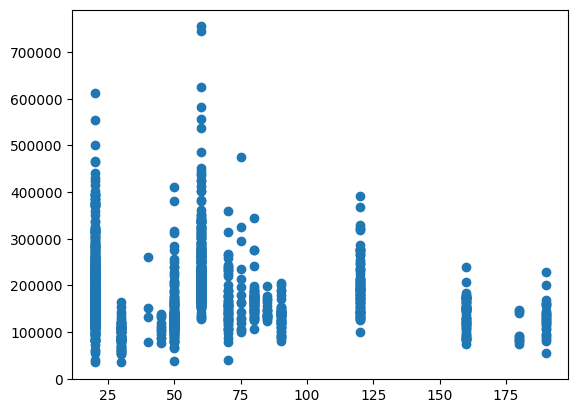

In [7]:
plt.scatter(x='MSSubClass',y='SalePrice',data=train_df)

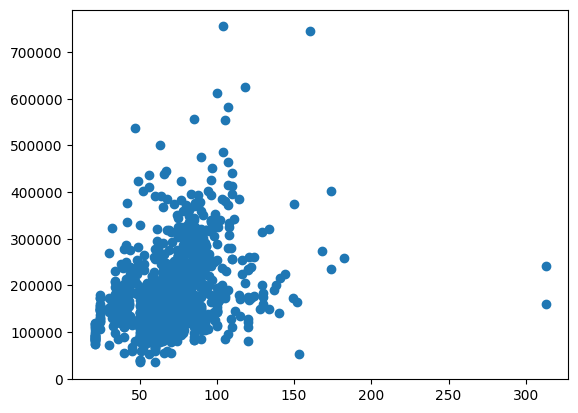

In [8]:
plt.scatter(x='LotFrontage',y='SalePrice',data=train_df)

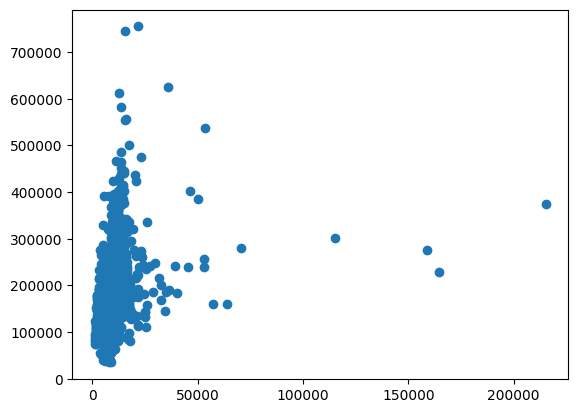

In [9]:
plt.scatter(x='LotArea',y='SalePrice',data=train_df)

In [10]:
train_df.query('LotFrontage > 300')
#934,1298


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
934,935,20,RL,313.0,27650,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,11,2008,WD,Normal,242000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


In [11]:
train_df.query('LotArea>55000')
#249,313,335,451,706,1298,1396

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
249,250,50,RL,NaN,159000,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,Shed,500,6,2007,WD,Normal,277000
313,314,20,RL,150.0,215245,Pave,NaN,IR3,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,375000
335,336,190,RL,NaN,164660,Grvl,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,Shed,700,8,2008,WD,Normal,228950
451,452,20,RL,62.0,70761,Pave,NaN,IR1,Low,AllPub,...,0,NaN,NaN,NaN,0,12,2006,WD,Normal,280000
706,707,20,RL,NaN,115149,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,302000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
1396,1397,20,RL,NaN,57200,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,160000


In [12]:
np.sort(stats.zscore(train_df['LotArea']))[-10:]


array([ 4.26847352,  4.28050017,  4.30826167,  4.6786823 ,  5.34886702,
        6.03779326, 10.48644876, 14.88128503, 15.44854173, 20.51827316])

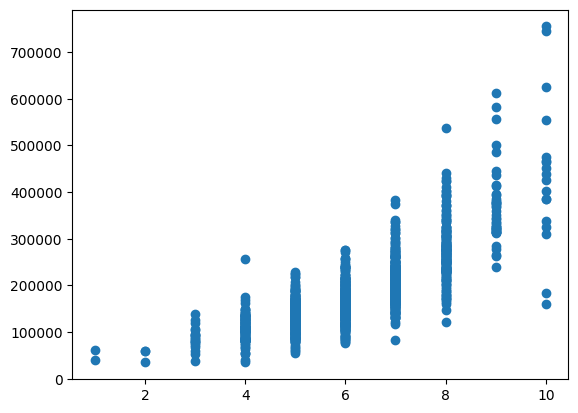

In [13]:
plt.scatter(x='OverallQual',y='SalePrice',data=train_df)

In [14]:
pd.DataFrame(train_df.isnull().sum().sort_values(ascending=False)).head(20)


,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [15]:
train_df['MiscFeature'].unique()

<StringArray>
[nan, 'Shed', 'Gar2', 'Othr', 'TenC']
Length: 5, dtype: str

In [16]:
train_df['Alley'].unique()

<StringArray>
[nan, 'Grvl', 'Pave']
Length: 3, dtype: str

In [17]:
train_df['Alley'].fillna('No',inplace=True)
test_df['Alley'].fillna('No',inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11380\821176631.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df['Alley'].fillna('No',inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_11380\821176631.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an

0       No
1       No
2       No
3       No
4       No
        ..
1454    No
1455    No
1456    No
1457    No
1458    No
Name: Alley, Length: 1459, dtype: str

In [18]:
train_df['MasVnrType'] = train_df['MasVnrType'].fillna('No')
test_df['MasVnrType'] = test_df['MasVnrType'].fillna('No')

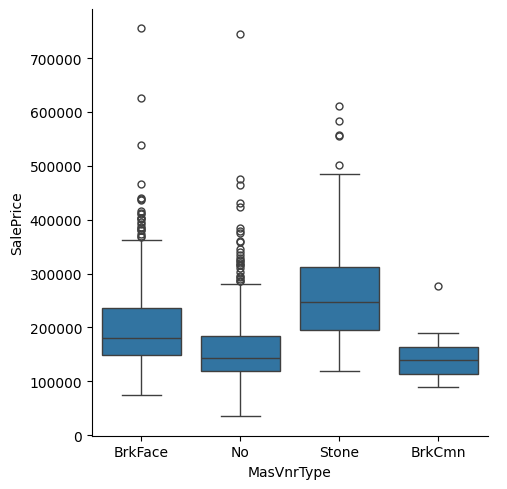

In [19]:
sns.catplot(data=train_df,x="MasVnrType",y='SalePrice',kind="box")

In [20]:
train_df['FireplaceQu'] = train_df['FireplaceQu'].fillna('No')
test_df['FireplaceQu'] = test_df['FireplaceQu'].fillna('No')

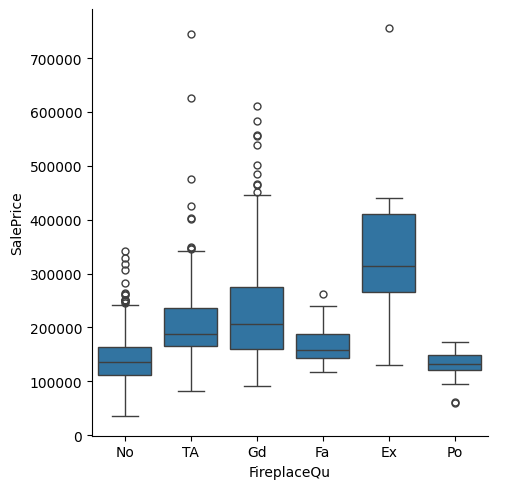

In [21]:
sns.catplot(data=train_df,x="FireplaceQu",y='SalePrice',kind="box")

In [22]:
train_df['LotFrontage'] = train_df['LotFrontage'].fillna(0)
test_df['LotFrontage'] = test_df['LotFrontage'].fillna(0)

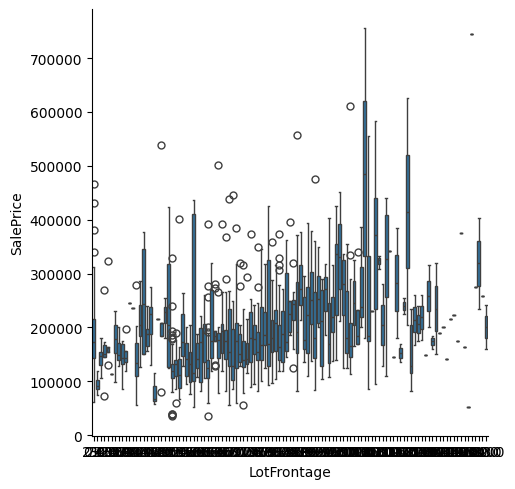

In [23]:
sns.catplot(data=train_df,x="LotFrontage",y='SalePrice',kind="box")

In [24]:
train_df['GarageQual'] = train_df['GarageQual'].fillna('No')
test_df['GarageQual'] = test_df['GarageQual'].fillna('No')

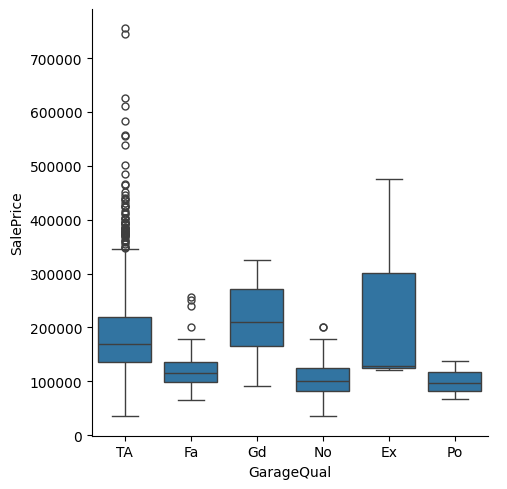

In [25]:
sns.catplot(data=train_df,x="GarageQual",y='SalePrice',kind="box")

In [26]:
train_df['GarageFinish'] = train_df['GarageFinish'].fillna('No')
test_df['GarageFinish'] = test_df['GarageFinish'].fillna('No')

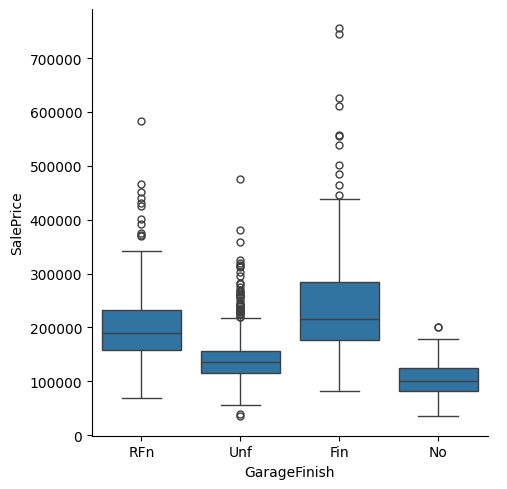

In [27]:
sns.catplot(data=train_df,x="GarageFinish",y='SalePrice',kind="box")

In [28]:
train_df['GarageYrBlt'] = train_df['GarageYrBlt'].fillna('No')
test_df['GarageYrBlt'] = test_df['GarageYrBlt'].fillna('No')

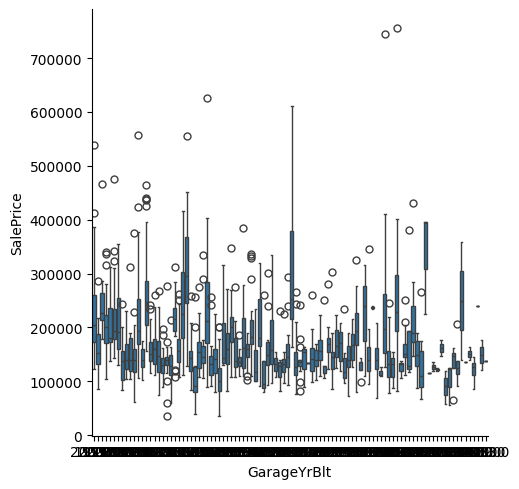

In [29]:
sns.catplot(data=train_df,x="GarageYrBlt",y='SalePrice',kind="box")

In [30]:
train_df['GarageType'] = train_df['GarageType'].fillna('No')
test_df['GarageType'] = test_df['GarageType'].fillna('No')

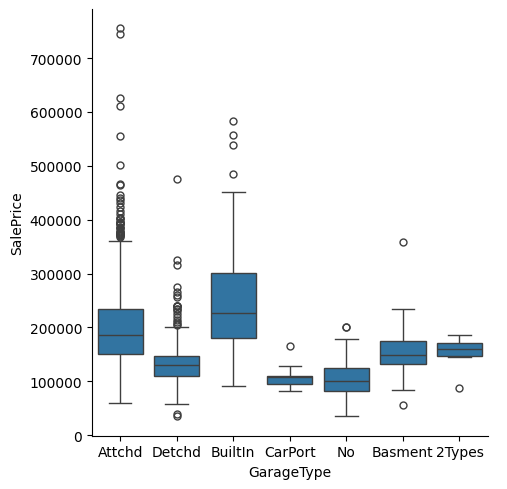

In [31]:
sns.catplot(data=train_df,x="GarageType",y='SalePrice',kind="box")

In [32]:
train_df['GarageCond'] = train_df['GarageCond'].fillna('No')
test_df['GarageCond'] = test_df['GarageCond'].fillna('No')

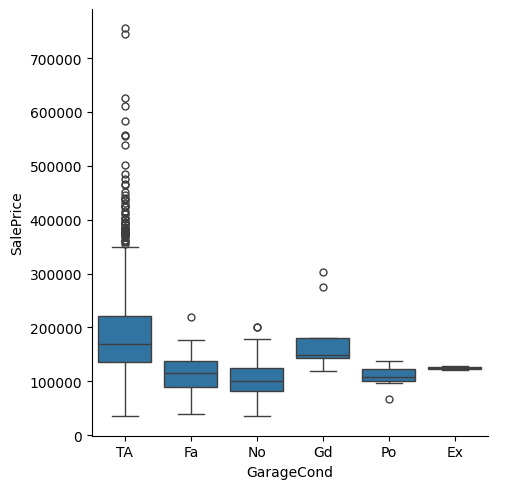

In [33]:
sns.catplot(data=train_df,x="GarageCond",y='SalePrice',kind="box")

In [34]:
train_df['BsmtFinType2'] = train_df['BsmtFinType2'].fillna('No')
test_df['BsmtFinType2'] = test_df['BsmtFinType2'].fillna('No')

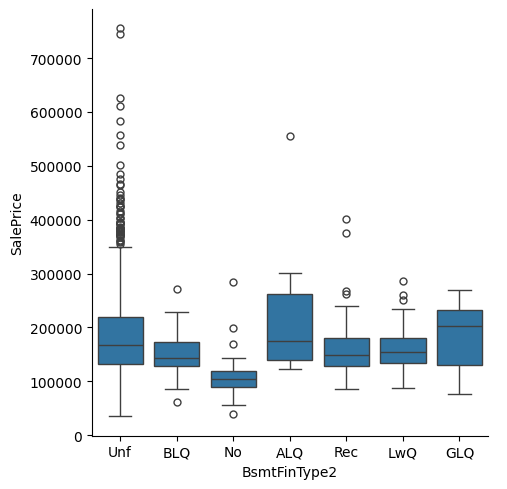

In [35]:
sns.catplot(data=train_df,x="BsmtFinType2",y='SalePrice',kind="box")

In [36]:
train_df['BsmtExposure'] = train_df['BsmtExposure'].fillna('No')
test_df['BsmtExposure'] = test_df['BsmtExposure'].fillna('No')

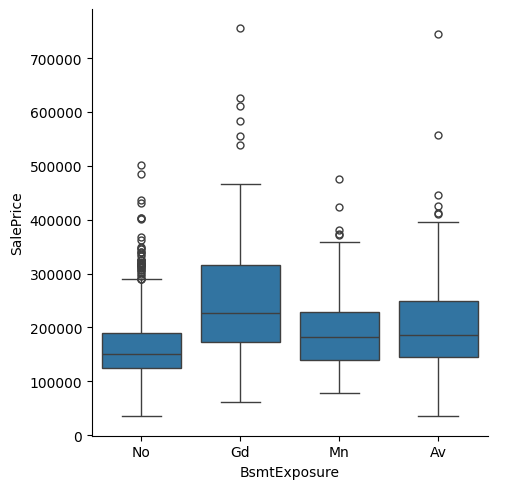

In [37]:
sns.catplot(data=train_df,x="BsmtExposure",y='SalePrice',kind="box")

In [38]:
train_df['BsmtCond'] = train_df['BsmtCond'].fillna('No')
test_df['BsmtCond'] = test_df['BsmtCond'].fillna('No')

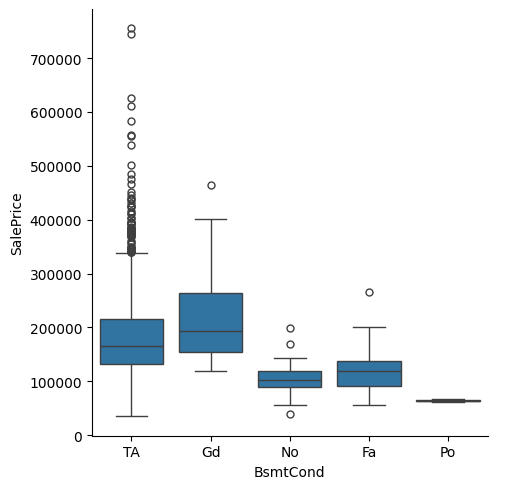

In [39]:
sns.catplot(data=train_df,x="BsmtCond",y='SalePrice',kind="box")

In [40]:
train_df['BsmtQual'] = train_df['BsmtQual'].fillna('No')
test_df['BsmtQual'] = test_df['BsmtQual'].fillna('No')



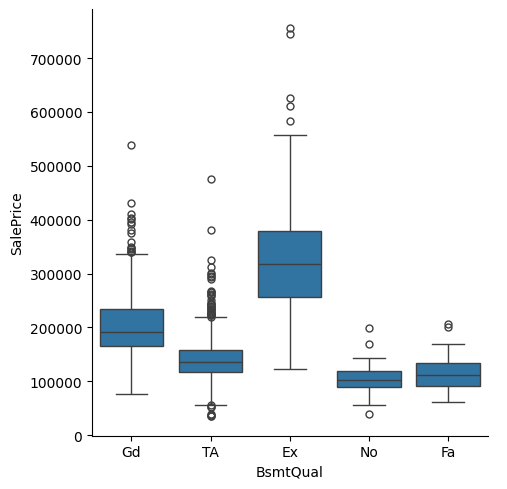

In [41]:
sns.catplot(data=train_df,x="BsmtQual",y='SalePrice',kind="box")

In [42]:
train_df['BsmtFinType1'] = train_df['BsmtFinType1'].fillna('No')
test_df['BsmtFinType1'] = test_df['BsmtFinType1'].fillna('No')

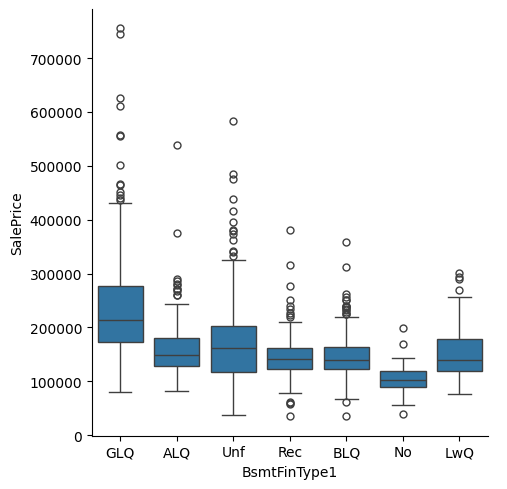

In [43]:
sns.catplot(data=train_df,x="BsmtFinType1",y='SalePrice',kind="box")

In [44]:
train_df['MasVnrArea'] = train_df['MasVnrArea'].fillna(0)
test_df['MasVnrArea'] = test_df['MasVnrArea'].fillna(0)

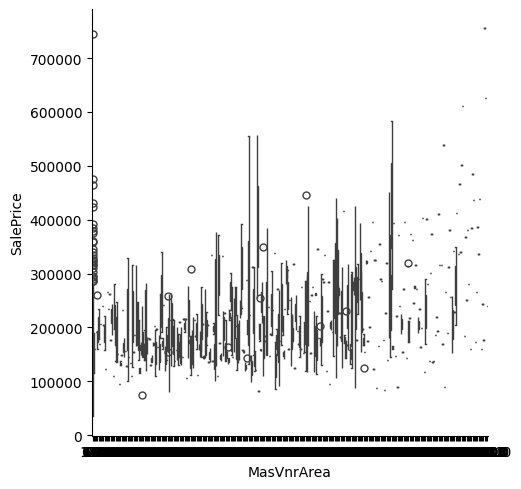

In [45]:
sns.catplot(data=train_df,x="MasVnrArea",y='SalePrice',kind="box")

In [46]:
train_df['Electrical'] = train_df['Electrical'].fillna('No')
test_df['Electrical'] = test_df['Electrical'].fillna('No')

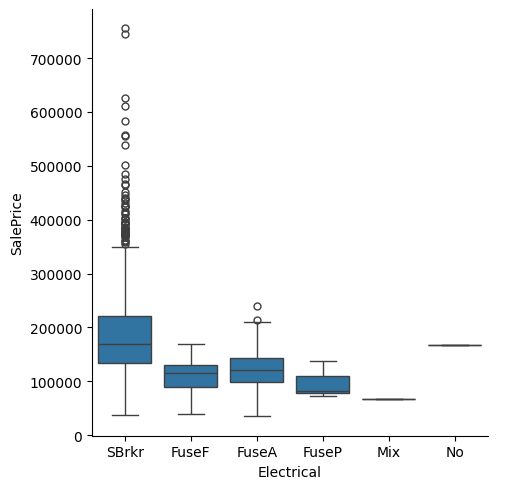

In [47]:
sns.catplot(data=train_df,x="Electrical",y='SalePrice',kind="box")

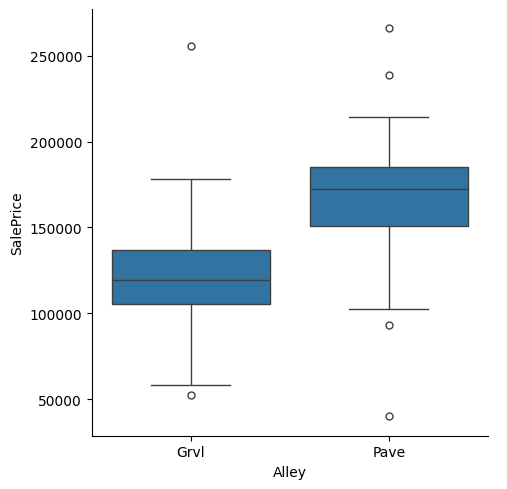

In [48]:
sns.catplot(data=train_df,x="Alley",y='SalePrice',kind="box")

In [49]:
train_df['Alley'].unique()

<StringArray>
[nan, 'Grvl', 'Pave']
Length: 3, dtype: str

In [50]:
train_df['Alley'] = train_df['Alley'].fillna('No')
test_df['Alley'] = test_df['Alley'].fillna('No')

In [51]:
train_df['Fence'].unique()

<StringArray>
[nan, 'MnPrv', 'GdWo', 'GdPrv', 'MnWw']
Length: 5, dtype: str

In [52]:
train_df['Fence'] = train_df['Fence'].fillna('No')
test_df['Fence'] = test_df['Fence'].fillna('No')

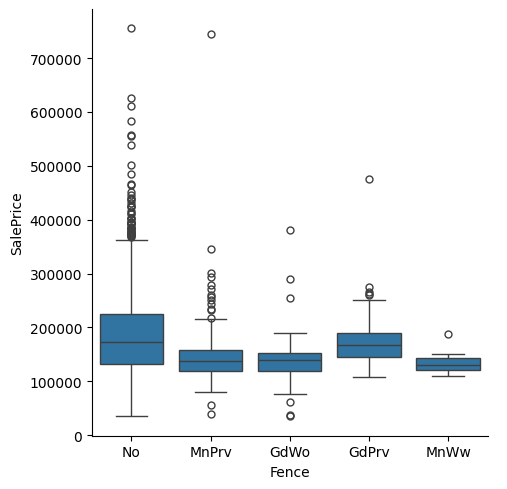

In [53]:
sns.catplot(data=train_df,x="Fence",y='SalePrice',kind="box")

In [54]:
train_df=train_df.drop(columns=['PoolQC','MiscFeature','Alley','Fence','GarageYrBlt','GarageCond','BsmtFinType2'])


In [55]:
test_df=test_df.drop(columns=['PoolQC','MiscFeature','Alley','Fence','GarageYrBlt','GarageCond','BsmtFinType2'])

In [56]:
#Feature Engineering

In [57]:
train_df['houseage']=train_df['YrSold']-train_df['YearBuilt']
test_df['houseage']=test_df['YrSold']-test_df['YearBuilt']

In [58]:
train_df['houserermodelage']=train_df['YrSold']- train_df['YearRemodAdd']
test_df['houserermodelage']=test_df['YrSold']- test_df['YearRemodAdd']

In [59]:
train_df['totalsf']=train_df['1stFlrSF']+train_df['2ndFlrSF']+train_df['BsmtFinSF1']+train_df['BsmtFinSF2']
test_df['totalsf']=test_df['1stFlrSF']+test_df['2ndFlrSF']+test_df['BsmtFinSF1']+test_df['BsmtFinSF2']

In [60]:
train_df['totalarea']=train_df['GrLivArea']+train_df['TotalBsmtSF']
test_df['totalarea']=test_df['GrLivArea']+test_df['TotalBsmtSF']

In [61]:
train_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageCars', 'GarageArea',
       'GarageQual', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3Ssn

In [62]:
train_df['totalbaths']=train_df['BsmtFullBath']+train_df['FullBath']+0.5*train_df['BsmtHalfBath']+ 0.5*train_df['HalfBath']
test_df['totalbaths']=test_df['BsmtFullBath']+test_df['FullBath']+0.5*test_df['BsmtHalfBath']+ 0.5*test_df['HalfBath']

In [63]:
train_df['totalporchsf']=train_df['OpenPorchSF']+train_df['3SsnPorch']+train_df['EnclosedPorch']
test_df['totalporchsf']=test_df['OpenPorchSF']+test_df['3SsnPorch']+test_df['EnclosedPorch']

In [64]:
train_df=train_df.drop(columns=['Id','YrSold','YearBuilt','YearRemodAdd','1stFlrSF','2ndFlrSF','BsmtFinSF1','BsmtFinSF2','GrLivArea','TotalBsmtSF','BsmtFullBath','FullBath','BsmtHalfBath','OpenPorchSF','3SsnPorch','EnclosedPorch'])
test_df=test_df.drop(columns=['Id','YrSold','YearBuilt','YearRemodAdd','1stFlrSF','2ndFlrSF','BsmtFinSF1','BsmtFinSF2','GrLivArea','TotalBsmtSF','BsmtFullBath','FullBath','BsmtHalfBath','OpenPorchSF','3SsnPorch','EnclosedPorch'])


<Axes: >

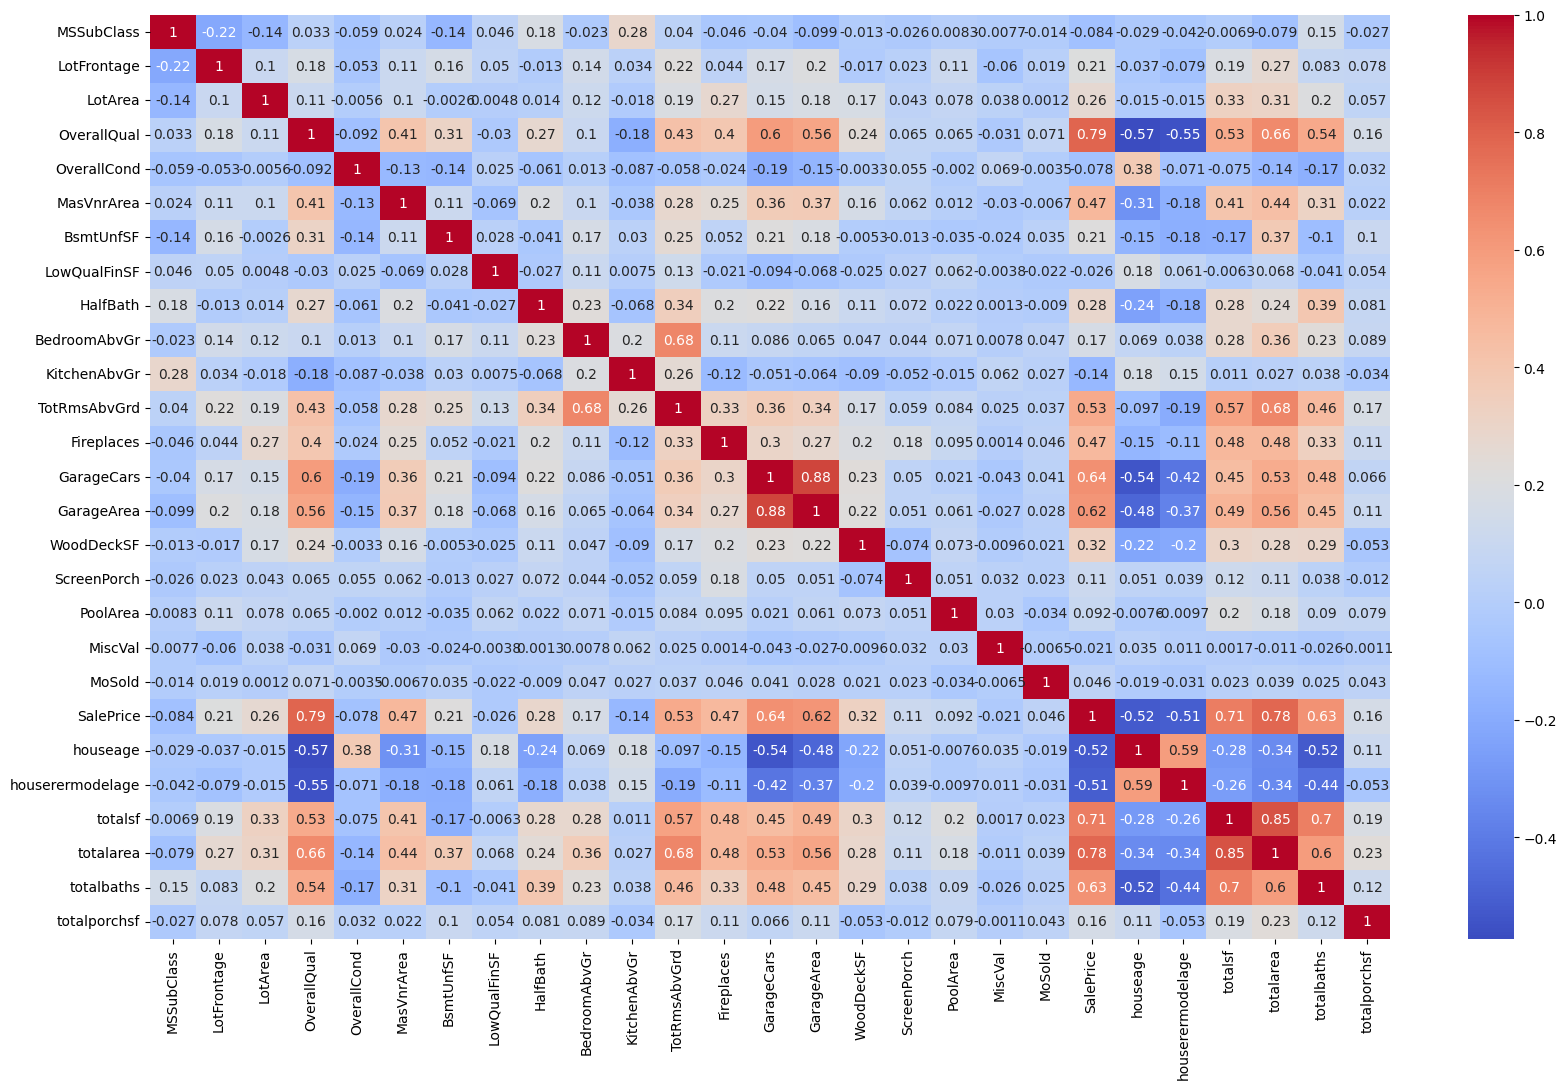

In [65]:
correlation=train_df.corr(numeric_only=True)
plt.figure(figsize=(20,12))
sns.heatmap(correlation,annot=True,cmap='coolwarm')


In [66]:
train_df=train_df.drop(columns=['GarageArea'])

In [67]:
test_df=test_df.drop(columns=['GarageArea'])

<Axes: xlabel='SalePrice', ylabel='Count'>

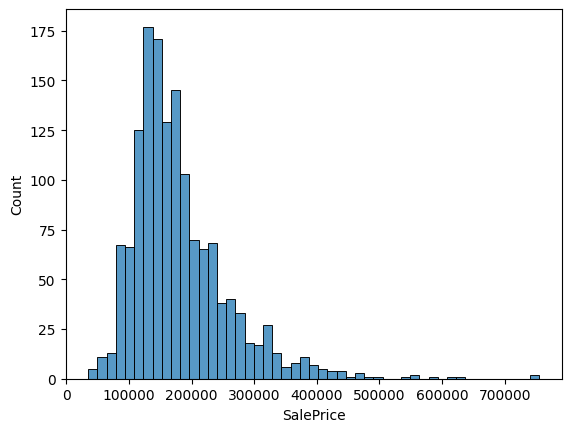

In [68]:
sns.histplot(train_df,x=train_df['SalePrice'])

In [69]:
train_df.dtypes[train_df.dtypes=='str']

MSZoning         str
Street           str
LotShape         str
LandContour      str
Utilities        str
LotConfig        str
LandSlope        str
Neighborhood     str
Condition1       str
Condition2       str
BldgType         str
HouseStyle       str
RoofStyle        str
RoofMatl         str
Exterior1st      str
Exterior2nd      str
MasVnrType       str
ExterQual        str
ExterCond        str
Foundation       str
BsmtQual         str
BsmtCond         str
BsmtExposure     str
BsmtFinType1     str
Heating          str
HeatingQC        str
CentralAir       str
Electrical       str
KitchenQual      str
Functional       str
FireplaceQu      str
GarageType       str
GarageFinish     str
GarageQual       str
PavedDrive       str
SaleType         str
SaleCondition    str
dtype: object

In [70]:
num_cols=train_df.select_dtypes(include=['int64','float64']).columns
num_cols=num_cols.drop('SalePrice')

In [71]:
ode_cols=['LotShape','LandContour','Utilities','LandSlope','BsmtQual','BsmtFinType1','CentralAir','Functional', 
'FireplaceQu','GarageFinish','GarageQual','PavedDrive','ExterCond','KitchenQual','BsmtExposure',
          'HeatingQC','RoofStyle','Foundation']

In [72]:
ohe_cols=['Street','LotConfig','Neighborhood','Condition1','Condition2','BldgType','MasVnrType',
          'SaleType','Electrical','MSZoning','SaleCondition','HouseStyle','Exterior1st',
          'Exterior2nd','RoofMatl','ExterQual','Heating','BsmtCond','GarageType']

In [73]:
num_pipeline=Pipeline(steps=[('impute', SimpleImputer(strategy='mean')),     
                ('scaler', StandardScaler())]) 

In [74]:
ode_pipeline=Pipeline(steps=[
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('ode',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))])    

In [75]:
ohe_pipeline=Pipeline(steps=[
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('ode',OneHotEncoder(handle_unknown='ignore',sparse_output=False))])

In [76]:
col_trans=ColumnTransformer(transformers=[
    ('num_p', num_pipeline,num_cols),
    ('ode_p',ode_pipeline,ode_cols),
    ('ohe_p',ohe_pipeline,ohe_cols)],remainder='passthrough',n_jobs=-1)

In [77]:
pipeline=Pipeline(steps=[('preprocessing',col_trans)])

In [78]:
X=train_df.drop('SalePrice',axis=1)
y=train_df['SalePrice']

In [79]:
x_preprocessed=pipeline.fit_transform(X)


In [80]:
x_train,x_test,y_train,y_test=train_test_split(x_preprocessed,y,test_size=0.2,random_state=42)

In [81]:
lr=LinearRegression()

In [82]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [83]:
y_pred_lr=lr.predict(x_test)

In [84]:
mse=mean_squared_error(y_test,y_pred_lr)
mse

857160460.1255616

In [85]:
RFR=RandomForestRegressor(random_state=13)

In [86]:
param_grid={'max_depth':[5,10,15],
            'n_estimators':[100,250,500],
            'min_samples_split':[3,5,10]}

In [87]:
rfr_cv=GridSearchCV(RFR,param_grid,cv=5,scoring='neg_mean_squared_error',n_jobs=-1)

In [88]:
rfr_cv.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=13)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [3, 5, ...], 'n_estimators': [100, 250, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidat

In [89]:
y_pred_rfr=rfr_cv.predict(x_test)

In [90]:
np.sqrt(-1*rfr_cv.best_score_)

np.float64(30683.77701534107)

In [91]:
rfr_cv.best_params_

{'max_depth': 10, 'min_samples_split': 3, 'n_estimators': 100}

In [92]:
XGB=XGBRegressor(random_state=13)

In [93]:
param_grid={'learning_rate':[0.05,0.1,0.2],'n_estimators':[300],'max_depth':[3],'min_child_weight':[1,2,3],
            'gamma':[0,0.1,0.2],
            'subsample':[0.8,0.9,1.0],
            'colsample_bytree':[0.8,0.9,1.0]}

In [94]:
xgb_cv=GridSearchCV(XGB,param_grid,cv=5,scoring='neg_mean_squared_error',n_jobs=-1)

In [95]:
xgb_cv.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 0.9, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each 

In [96]:
np.sqrt(-1*xgb_cv.best_score_)


np.float64(26859.756305670384)

In [97]:
xgb_cv.best_params_

{'colsample_bytree': 0.9,
 'gamma': 0,
 'learning_rate': 0.2,
 'max_depth': 3,
 'min_child_weight': 2,
 'n_estimators': 300,
 'subsample': 0.9}

In [98]:

ridge=Ridge()

In [99]:
param_grid_ridge={
    'alpha':[0.05,0.1,1,3,5,10],
    'solver':['auto','svd','cholesky','lsqr','sparse_cg','sag']}

In [100]:
ridge_cv=GridSearchCV(ridge,param_grid_ridge,cv=5,scoring='neg_mean_squared_error',n_jobs=-1)

In [101]:
ridge_cv.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.05, 0.1, ...], 'solver': ['auto', 'svd', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : t

In [102]:
np.sqrt(-1*ridge_cv.best_score_)

np.float64(34509.866355631675)

In [103]:
print(y_train.describe())

count      1168.000000
mean     181441.541952
std       77263.583862
min       34900.000000
25%      130000.000000
50%      165000.000000
75%      214925.000000
max      745000.000000
Name: SalePrice, dtype: float64


In [104]:
GBR=GradientBoostingRegressor()

In [105]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 1.0]
}

In [106]:
GBR_cv=GridSearchCV(GBR,param_grid,cv=5,scoring='neg_mean_squared_error',n_jobs=-1)

In [ ]:
GBR_cv.fit(x_train,y_train)

In [ ]:
np.sqrt(-1*GBR_cv.best_score_)

In [ ]:
vr=VotingRegressor([('gbr',GBR_cv.best_estimator_),
                    ('xgb',xgb_cv.best_estimator_),
                    ('ridge',ridge_cv.best_estimator_)],weights=[2,3,1])

In [ ]:
vr.fit(x_train, y_train)  

In [ ]:
y_pred_vr=vr.predict(x_test)

In [ ]:
mean_squared_error(y_test,y_pred_vr)

In [ ]:
from sklearn.metrics import r2_score
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_vr)):.2f}")
print(f"R²   : {r2_score(y_test, y_pred_vr):.4f}")